In [1]:
import sys
print(sys.executable)

/Users/dipasmitadebroy/Documents/Artificial_Intelligence/ml_projects/movie-recommender/venv/bin/python


In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from surprise import NMF, Dataset, Reader
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, warnings

warnings.filterwarnings("ignore")
%matplotlib inline
print("✅ Imports done")

✅ Imports done


In [3]:
# Load and build surprise dataset

PROCESSED_DIR = "../data/processed/"
MODEL_DIR     = "../models/"
FIGURES_DIR   = "../reports/figures/"

train  = pd.read_parquet(PROCESSED_DIR + "train.parquet")
test   = pd.read_parquet(PROCESSED_DIR + "test.parquet")
y_true = test["rating"].values

reader   = Reader(rating_scale=(0.5, 5.0))
trainset = Dataset.load_from_df(train[["userId","movieId","rating"]], reader).build_full_trainset()

print(f"Train: {len(train):,} | Test: {len(test):,}")

Train: 19,784,257 | Test: 5,026,226


In [4]:
# Train NMF

nmf = NMF(n_factors=15, n_epochs=50, reg_pu=0.06, reg_qi=0.06, biased=True, verbose=True)
nmf.fit(trainset)
print("✅ NMF trained")

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29
Processing epoch 30
Processing epoch 31
Processing epoch 32
Processing epoch 33
Processing epoch 34
Processing epoch 35
Processing epoch 36
Processing epoch 37
Processing epoch 38
Processing epoch 39
Processing epoch 40
Processing epoch 41
Processing epoch 42
Processing epoch 43
Processing epoch 44
Processing epoch 45
Processing epoch 46
Processing epoch 47
Processing epoch 48
Processing epoch 49
✅ NMF trai

In [5]:
# Predict & Evaluate

preds_nmf = np.clip(
    [nmf.predict(r.userId, r.movieId).est for r in test.itertuples()], 0.5, 5.0
)

rmse_nmf = np.sqrt(mean_squared_error(y_true, preds_nmf))
mae_nmf  = mean_absolute_error(y_true, preds_nmf)

print("=" * 40)
print("📊 NMF")
print(f"   RMSE : {rmse_nmf:.4f}")
print(f"   MAE  : {mae_nmf:.4f}")
print("=" * 40)

nmf_results = {"model": "NMF", "RMSE": rmse_nmf, "MAE": mae_nmf}

📊 NMF
   RMSE : 0.8873
   MAE  : 0.6689


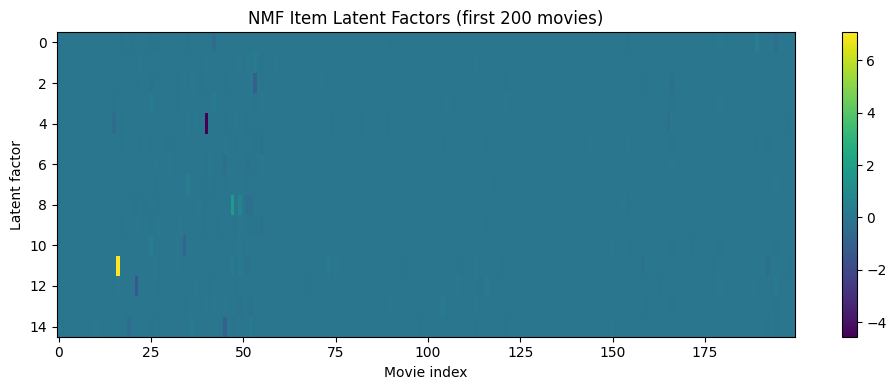

In [6]:
# Visualize Latent Factors

item_factors = nmf.qi   # shape: (n_items, n_factors)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(item_factors[:200].T, aspect="auto", cmap="viridis")
ax.set_title("NMF Item Latent Factors (first 200 movies)")
ax.set_xlabel("Movie index")
ax.set_ylabel("Latent factor")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR + "nmf_factors.png", dpi=150)
plt.show()

In [ ]:
# Save the model

joblib.dump({"model": nmf, "preds": preds_nmf, "results": nmf_results},
            MODEL_DIR + "nmf.joblib")
print("✅ NMF saved — move to 05_ncf.ipynb")

✅ NMF saved — move to 05_ncf.ipynb


: 